# Porównanie modeli predykcji BTC
Wczytuje wyniki z `models/training_report.json` i wygenerowane modele.
Uruchom najpierw: `python src/run_all.py`

In [62]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from config      import MODELS_DIR, HORIZONS
from data_loader import load_full, make_sequences, train_test_split_ts
from predict     import predict_one
from model_registry import get_model, all_names

plt.style.use('dark_background')
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.07
plt.rcParams['figure.figsize']  = (15, 5)

C = {'lstm': '#0066FF', 'blstm': '#00FFCC', 'conv1d': '#FF6B35', 'transformer': '#C084FC', 'real': '#F7931A'}

# Wczytaj raport
report_path = MODELS_DIR / 'training_report.json'
report = json.loads(report_path.read_text())
print(f"Raport z: {report['run_at']}")
print(f"Ranking: {report['ranking']}")

Raport z: 2026-06-16T19:56:44.173242
Ranking: ['transformer', 'blstm', 'lstm', 'conv1d']


## 1. Tabela metryk

In [63]:
rows = []
for name, r in report['models'].items():
    if r.get('status') != 'ok':
        continue
    m = r['metrics']
    rows.append({
        'Model':    name.upper(),
        'Okno':     r['window'],
        'Cechy':    r['n_features'],
        'Epoki':    r['epochs_run'],
        'Czas (s)': r['train_time_sec'],
        'MAE ($)':  m['mae'],
        'RMSE ($)': m['rmse'],
        'MAPE (%)': m['mape'],
        'DA (%)':   m['da'],
    })

df_metrics = pd.DataFrame(rows).set_index('Model')
df_metrics.style \
    .highlight_min(subset=['MAE ($)', 'RMSE ($)', 'MAPE (%)'], color='#0a3d0a') \
    .highlight_max(subset=['DA (%)'], color='#0a3d0a') \
    .format({'MAE ($)': '{:,.0f}', 'RMSE ($)': '{:,.0f}',
             'MAPE (%)': '{:.2f}', 'DA (%)': '{:.1f}'})

,Okno,Cechy,Epoki,Czas (s),MAE ($),RMSE ($),MAPE (%),DA (%)
Model,,,,,,,,
LSTM,60,6,28,50.800000,"1,379","1,955",1.87,52.5
BLSTM,14,6,77,65.200000,"1,312","1,877",1.78,50.3
CONV1D,30,6,39,32.500000,"1,386","1,930",1.87,49.2
TRANSFORMER,30,6,150,238.200000,"1,280","1,866",1.74,48.0


## 2. Wykresy słupkowe metryk

In [21]:
names  = df_metrics.index.tolist()
colors = [C.get(n.lower(), '#888888') for n in names]
x      = np.arange(len(names))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Porównanie metryk — ' + ' vs '.join(df_metrics.index.tolist()), fontsize=14)

for ax, col, title, lower_better in [
    (axes[0], 'MAPE (%)', 'MAPE  (niżej = lepiej)',  True),
    (axes[1], 'RMSE ($)', 'RMSE  (niżej = lepiej)',  True),
    (axes[2], 'DA (%)',   'DA    (wyżej = lepiej)',   False),
]:
    vals = df_metrics[col].values
    bars = ax.bar(x, vals, color=colors, alpha=0.85, width=0.55)
    best = int(np.argmin(vals) if lower_better else np.argmax(vals))
    bars[best].set_edgecolor('white')
    bars[best].set_linewidth(2)

    for bar, v in zip(bars, vals):
        fmt = f'{v:.2f}' if col != 'RMSE ($)' else f'${v:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=10)

    if col == 'DA (%)':
        ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='rzut monetą (50%)')
        ax.legend(fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/metrics_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Predykcje na zbiorze testowym vs rzeczywistość

In [65]:
df_full, available = load_full()
TEST_DAYS = 180

fig, ax = plt.subplots(figsize=(16, 6))

real = df_full['price'].iloc[-TEST_DAYS:]
ax.plot(real.index, real.values, color=C['real'], lw=2.2, label='Cena rzeczywista', zorder=10)

for model_name in all_names():
    model = get_model(model_name)
    if not model.is_trained():
        continue
    model.load()

    features = model._features
    X, y, _, scaler_price, dates = make_sequences(df_full, features, model.window)
    _, X_test, _, y_test, _, dates_test = train_test_split_ts(X, y, dates, TEST_DAYS)

    raw = model._keras_model.predict(X_test, verbose=0)
    pred_scaled  = raw[0] if isinstance(raw, (list, tuple)) else raw
    pred_returns = model._scaler_price.inverse_transform(pred_scaled).flatten()
    real_prev    = df_full['price'].iloc[-len(pred_returns)-1:-1].values
    pred_prices  = pd.Series(
        real_prev * np.exp(pred_returns),
        index=dates_test,
    )

    ax.plot(pred_prices.index, pred_prices.values,
            color=C[model_name], lw=1.6, linestyle='--',
            label=f'{model_name.upper()} (anchored)', alpha=0.9)

ax.set_title('Predykcja na zbiorze testowym (ostatnie 180 dni) — wszystkie modele', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/test_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] LSTM  (window=60, features=6, val_loss=0.015531)
  [loaded] BLSTM  (window=14, features=6, val_loss=0.026109)
  [loaded] CONV1D  (window=30, features=6, val_loss=0.016294)
  [loaded] TRANSFORMER  (window=30, features=6, val_loss=0.014416)


## 4. Analiza reszt (residuals)

In [66]:
trained_models = [n for n in all_names()
                  if report['models'].get(n, {}).get('status') == 'ok']

fig, axes = plt.subplots(len(trained_models), 2,
                         figsize=(16, 4 * len(trained_models)),
                         squeeze=False)
fig.suptitle('Analiza reszt — wszystkie modele', fontsize=14)

for row, model_name in enumerate(trained_models):
    model = get_model(model_name)
    model.load()

    features = model._features
    X, y, _, _, dates = make_sequences(df_full, features, model.window)
    _, X_test, _, _, _, dates_test = train_test_split_ts(X, y, dates, TEST_DAYS)

    raw = model._keras_model.predict(X_test, verbose=0)
    pred_scaled  = raw[0] if isinstance(raw, (list, tuple)) else raw
    pred_returns = model._scaler_price.inverse_transform(pred_scaled).flatten()
    real_prev    = df_full['price'].iloc[-len(pred_returns)-1:-1].values
    pred_prices  = real_prev * np.exp(pred_returns)
    true_prices  = df_full['price'].iloc[-len(pred_returns):].values
    residuals    = true_prices - pred_prices

    color = C[model_name]

    # Reszty w czasie
    ax_l = axes[row][0]
    ax_l.plot(dates_test, residuals, color=color, lw=1.2, alpha=0.85)
    ax_l.axhline(0, color='white', lw=0.8, linestyle='--')
    ax_l.fill_between(dates_test, residuals, 0,
                      where=(residuals > 0), color=color, alpha=0.12)
    ax_l.fill_between(dates_test, residuals, 0,
                      where=(residuals < 0), color=color, alpha=0.06)
    ax_l.set_title(f'{model_name.upper()} — reszty w czasie', fontsize=11)
    ax_l.set_ylabel('Błąd ($)')
    ax_l.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # Histogram reszt
    ax_r = axes[row][1]
    ax_r.hist(residuals, bins=30, color=color, alpha=0.75, edgecolor='none')
    ax_r.axvline(0,               color='white', lw=1.2, linestyle='--')
    ax_r.axvline(np.mean(residuals), color='yellow', lw=1.2,
                 linestyle='-', label=f'mean={np.mean(residuals):,.0f}')
    ax_r.set_title(f'{model_name.upper()} — rozkład reszt', fontsize=11)
    ax_r.set_xlabel('Błąd ($)')
    ax_r.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/residuals_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

  [loaded] LSTM  (window=60, features=6, val_loss=0.015531)
  [loaded] BLSTM  (window=14, features=6, val_loss=0.026109)
  [loaded] CONV1D  (window=30, features=6, val_loss=0.016294)
  [loaded] TRANSFORMER  (window=30, features=6, val_loss=0.014416)


## 5. Prognoza przyszłości — wszystkie modele na 4 horyzontach

In [67]:
HORIZONS_PLOT = {'1 tydzień': 7, '1 miesiąc': 30, '3 miesiące': 90, '6 miesięcy': 180}
MAX_STEPS     = 180

# Wygeneruj prognozy raz dla wszystkich modeli
forecasts = {}
for model_name in trained_models:
    try:
        forecasts[model_name.upper()] = predict_one(model_name, MAX_STEPS)
    except Exception as e:
        print(f'{model_name}: {e}')

last_price = df_full['price'].iloc[-1]
last_date  = df_full.index[-1]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Prognoza BTC/USD — ' + ' vs '.join(forecasts.keys()), fontsize=15, y=1.01)

for ax, (h_name, h_days) in zip(axes.flatten(), HORIZONS_PLOT.items()):
    hist = df_full['price'].iloc[-90:]
    ax.plot(hist.index, hist.values, color=C['real'], lw=2.2,
            label='Historia (90 dni)', zorder=10)
    ax.axvline(last_date, color='white', lw=0.8, linestyle=':', alpha=0.5)

    for label, series in forecasts.items():
        sliced = series.iloc[:h_days]
        color  = C.get(label.lower(), '#888888')
        ax.plot(sliced.index, sliced.values,
                color=color, lw=2.0, label=label)

        val  = sliced.iloc[-1]
        chg  = (val / last_price - 1) * 100
        sign = '+' if chg >= 0 else ''
        ax.annotate(
            f'${val:,.0f}\n({sign}{chg:.1f}%)',
            xy=(sliced.index[-1], val),
            xytext=(6, 0), textcoords='offset points',
            fontsize=7.5, color=color,
        )

    ax.set_title(f'{h_name}  ({h_days} dni)', fontsize=12)
    ax.set_ylabel('BTC/USD')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.legend(fontsize=9, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('../data/processed/forecast_all_models.png', dpi=130, bbox_inches='tight')
plt.show()

  [loaded] LSTM  (window=60, features=6, val_loss=0.015531)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] BLSTM  (window=14, features=6, val_loss=0.026109)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] CONV1D  (window=30, features=6, val_loss=0.016079)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] TRANSFORMER  (window=30, features=6, val_loss=0.014399)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']


## 6. Dryft prognoz vs ostatnia znana cena

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.axhline(0, color='white', lw=1.2, linestyle='--', alpha=0.5, label='Ostatnia cena (0%)')

days_axis = np.arange(1, MAX_STEPS + 1)
for label, series in forecasts.items():
    drift = (series.values / last_price - 1) * 100
    color = C.get(label.lower(), '#888888')
    ax.plot(days_axis, drift, color=color, lw=2.0, label=label)
    ax.fill_between(days_axis, drift, 0,
                    where=(drift > 0), color=color, alpha=0.07)
    ax.fill_between(days_axis, drift, 0,
                    where=(drift < 0), color=color, alpha=0.04)

for h_days, h_name in [(7,'1 tyg.'), (30,'1 mies.'), (90,'3 mies.'), (180,'6 mies.')]:
    ax.axvline(h_days, color='white', lw=0.5, linestyle=':', alpha=0.3)
    ax.text(h_days+1, ax.get_ylim()[0] * 0.95, h_name,
            fontsize=8, color='white', alpha=0.45)

ax.set_xlabel('Dzień prognozy')
ax.set_ylabel('Zmiana vs ostatnia cena (%)')
ax.set_title('Dryft prognoz — jak modele odchylają się od ostatniej ceny?', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/forecast_drift.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Tabela prognoz punktowych

In [26]:
print(f'Ostatnia cena: ${last_price:,.0f}  ({last_date.date()})')
print()

header = f"{'Horyzont':<16} {'Dni':>4}  {'Data':^12}"
for label in forecasts:
    header += f"  {label:>16}"
print(header)
print('─' * len(header))

for h_name, h_days in HORIZONS_PLOT.items():
    d   = (last_date + pd.Timedelta(days=h_days)).date()
    row = f'  {h_name:<14} {h_days:>4}  {str(d):^12}'
    for series in forecasts.values():
        val  = series.iloc[h_days - 1]
        chg  = (val / last_price - 1) * 100
        sign = '+' if chg >= 0 else ''
        row += f'  ${val:>8,.0f} ({sign}{chg:.1f}%)'
    print(row)

Ostatnia cena: $66,290  (2026-06-15)

Horyzont          Dni      Data                  LSTM             BLSTM            CONV1D       TRANSFORMER
───────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 tydzień         7   2026-06-22   $  68,977 (+4.1%)  $  60,474 (-8.8%)  $  65,417 (-1.3%)  $  62,144 (-6.3%)
  1 miesiąc        30   2026-07-15   $  79,293 (+19.6%)  $  60,397 (-8.9%)  $  65,876 (-0.6%)  $  49,293 (-25.6%)
  3 miesiące       90   2026-09-13   $ 114,702 (+73.0%)  $  74,918 (+13.0%)  $  68,310 (+3.0%)  $  27,264 (-58.9%)
  6 miesięcy      180   2026-12-12   $ 199,656 (+201.2%)  $ 103,702 (+56.4%)  $  72,144 (+8.8%)  $  11,210 (-83.1%)


---
## 📈 Historia treningu

Wykresy loss/val_loss (i MAE jeśli dostępne) dla każdego wytrenowanego modelu.  
Wymagają pliku `models/<name>/history.npy` — generowanego automatycznie przez `model.train()`.  
PNG z tymi samymi wykresami zapisywany jest równolegle do `models/<name>/training_history.png`.


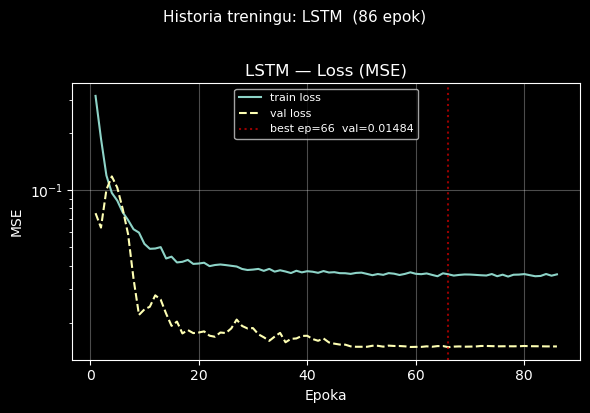

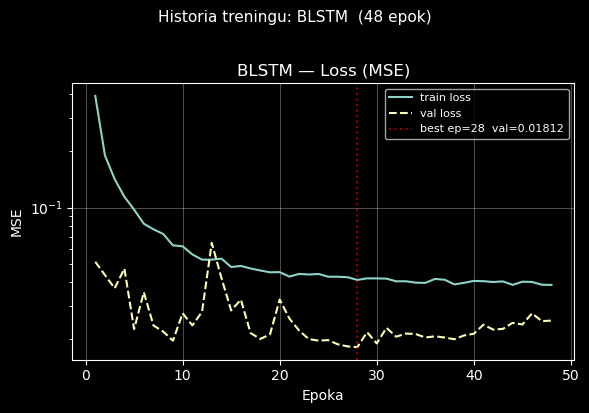

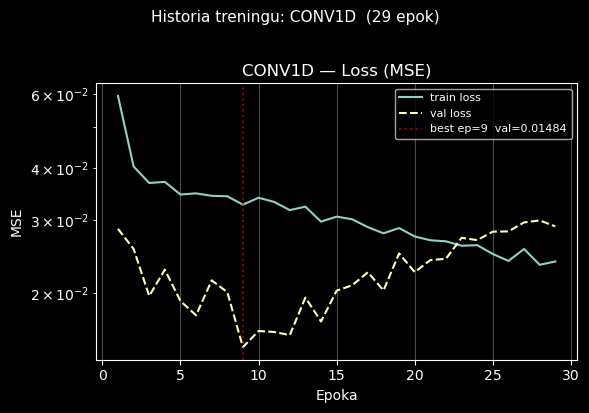

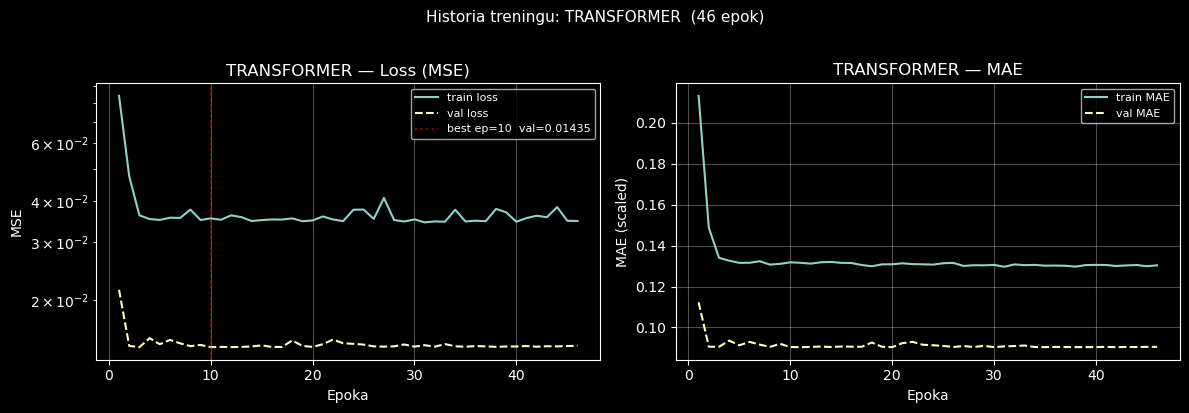

In [79]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from model_registry import all_names


def plot_all_histories(models_dir='../models'):
    """
    Ładuje history.npy dla każdego wytrenowanego modelu i rysuje wykresy inline.
    Jeśli history.npy nie istnieje (stary trening bez zapisu), wyświetla PNG jeśli dostępne.
    """
    models_dir = pathlib.Path(models_dir)

    for name in all_names():
        hist_path = models_dir / name / 'history.npy'
        png_path  = models_dir / name / 'training_history.png'

        if hist_path.exists():
            h = np.load(str(hist_path), allow_pickle=True).item()
        elif png_path.exists():
            print(f'{name.upper()}: brak history.npy — wyświetlam PNG')
            img = plt.imread(str(png_path))
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.imshow(img)
            ax.axis('off')
            fig.tight_layout()
            display(fig)
            plt.close(fig)
            continue
        else:
            print(f'{name.upper()}: brak danych historii — uruchom train.py')
            continue

        loss_key     = 'price_output_loss' if 'price_output_loss' in h else 'loss'
        val_loss_key = next((k for k in ('val_price_output_loss', 'val_loss') if k in h), None)
        mae_key      = next((k for k in ('price_output_mae', 'mae') if k in h), None)
        val_mae_key  = next((k for k in ('val_price_output_mae', 'val_mae') if k in h), None)

        n_plots = 2 if mae_key else 1
        fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
        if n_plots == 1:
            axes = [axes]

        epochs = range(1, len(h[loss_key]) + 1)

        # ── Panel 1: Loss ──────────────────────────────────────────────
        ax = axes[0]
        ax.plot(epochs, h[loss_key], label='train loss', lw=1.5)
        if val_loss_key:
            ax.plot(epochs, h[val_loss_key], label='val loss', lw=1.5, ls='--')
            best_ep  = int(np.argmin(h[val_loss_key])) + 1
            best_val = min(h[val_loss_key])
            ax.axvline(best_ep, color='red', ls=':', alpha=0.6,
                       label=f'best ep={best_ep}  val={best_val:.5f}')
        ax.set_title(f'{name.upper()} — Loss (MSE)')
        ax.set_xlabel('Epoka')
        ax.set_ylabel('MSE')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')

        # ── Panel 2: MAE ───────────────────────────────────────────────
        if mae_key:
            ax2 = axes[1]
            ax2.plot(epochs, h[mae_key], label='train MAE', lw=1.5)
            if val_mae_key:
                ax2.plot(epochs, h[val_mae_key], label='val MAE', lw=1.5, ls='--')
            ax2.set_title(f'{name.upper()} — MAE')
            ax2.set_xlabel('Epoka')
            ax2.set_ylabel('MAE (scaled)')
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

        fig.suptitle(
            f'Historia treningu: {name.upper()}  ({len(h[loss_key])} epok)',
            fontsize=11, y=1.02)
        fig.tight_layout()
        display(fig)
        plt.close(fig)


plot_all_histories('../models')


---
## 🔬 Porównanie zbieżności — overlay

Val loss wszystkich modeli na jednym wykresie.  
**Lewy panel**: absolutna oś epok — widać który model trenuje się najkrócej.  
**Prawy panel**: znormalizowany progress [0,1] — widać który schodzi najniżej.


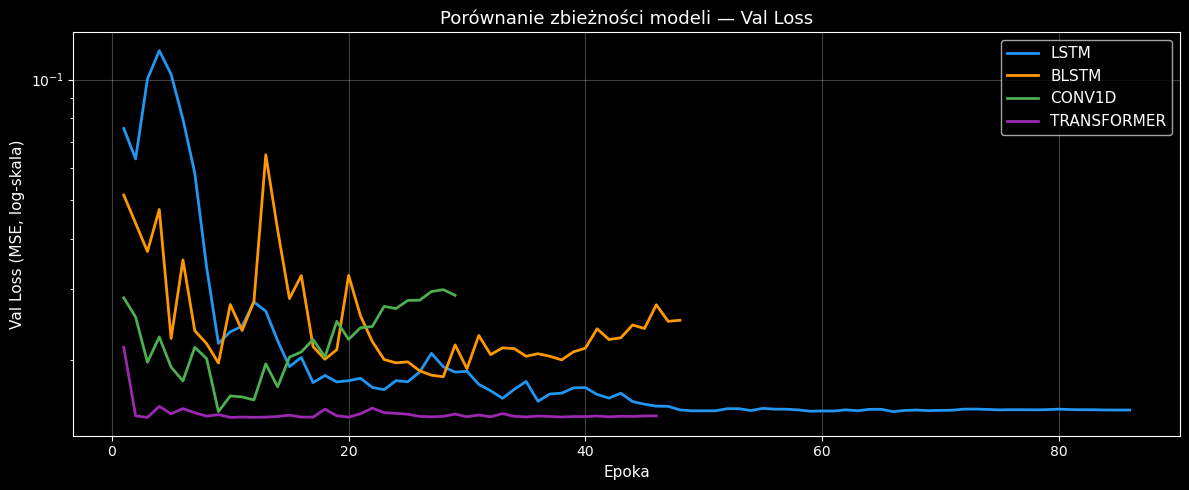

In [78]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from pathlib import Path
from model_registry import all_names

COLORS = {
    'lstm':        '#2196F3',
    'blstm':       '#FF9800',
    'conv1d':      '#4CAF50',
    'transformer': '#9C27B0',
}

def plot_all_histories(models_dir='../models'):
    models_dir = Path(models_dir)
    fig, ax = plt.subplots(figsize=(12, 5))

    any_plotted = False
    for name in all_names():
        hist_path = models_dir / name / 'history.npy'
        if not hist_path.exists():
            print(f"  Brak {hist_path} — pomijam {name}")
            continue

        h   = np.load(hist_path, allow_pickle=True).item()
        col = COLORS.get(name, '#888888')

        val_loss_key = next(
            (k for k in ('val_price_output_loss', 'val_loss') if k in h), None
        )
        if not val_loss_key:
            print(f"  Brak val_loss w history — pomijam {name}")
            continue

        epochs = np.arange(1, len(h[val_loss_key]) + 1)
        ax.plot(epochs, h[val_loss_key], color=col, lw=2.0, label=name.upper())
        any_plotted = True

    if not any_plotted:
        print("Brak plików history.npy — najpierw wytrenuj modele.")
        plt.close(fig)
        return

    ax.set_yscale('log')
    ax.set_xlabel('Epoka', fontsize=11)
    ax.set_ylabel('Val Loss (MSE, log-skala)', fontsize=11)
    ax.set_title('Porównanie zbieżności modeli — Val Loss', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.25)

    fig.tight_layout()
    display(fig)
    plt.close(fig)

plot_all_histories('../models')